# Tutorial 01: Clarifying Requirements for ML Systems

---

## Welcome!

Welcome to the second tutorial in our ML System Design series! In the previous notebook, we learned about the fundamentals of ML systems. Now, we'll dive into the **most critical first step** in any ML system design: **clarifying requirements**.

> **"Building the right thing is more important than building the thing right."**

Think about building a house. Before laying a single brick, you need to know:
- How many people will live there?
- What's the budget?
- How many bedrooms and bathrooms?
- What's the climate like?

Similarly, before building an ML system, we need to understand what we're building, why we're building it, and what constraints we're working with.

---

## Learning Objectives

By the end of this tutorial, you will be able to:

| # | Objective | Why It Matters |
|---|-----------|----------------|
| 1 | **Ask the right clarifying questions** | Prevents building the wrong system |
| 2 | **Translate business goals to technical requirements** | Bridges the gap between stakeholders and engineers |
| 3 | **Identify and document system constraints** | Ensures feasible design decisions |
| 4 | **Estimate scale and performance needs** | Determines architecture and infrastructure |
| 5 | **Create comprehensive requirements specifications** | Provides a clear roadmap for development |
| 6 | **Recognize trade-offs between competing priorities** | Enables informed decision-making |

---

## Setup

Let's import the libraries we'll use throughout this tutorial.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Dict
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

print("Setup complete! Let's learn about clarifying requirements.")

Setup complete! Let's learn about clarifying requirements.


---

## Part 1: Why Requirements Matter

### The House-Building Analogy

Imagine you're hired to build a house, and you immediately start laying the foundation. After weeks of work, the client says:

> *"Wait, I wanted a mobile home that I could move to different locations!"*

All your work is wasted because you didn't clarify requirements upfront.

**The same happens in ML systems:**

| What You Built | What They Wanted | The Cost |
|---------------|------------------|----------|
| Batch recommendations (updated daily) | Real-time recommendations | Redesign entire architecture |
| Cloud-based model | On-device model for privacy | Rewrite and compress model |
| Maximum accuracy model | Explainable model | Start over with different approach |

### The Cost of Fixing Issues at Different Stages

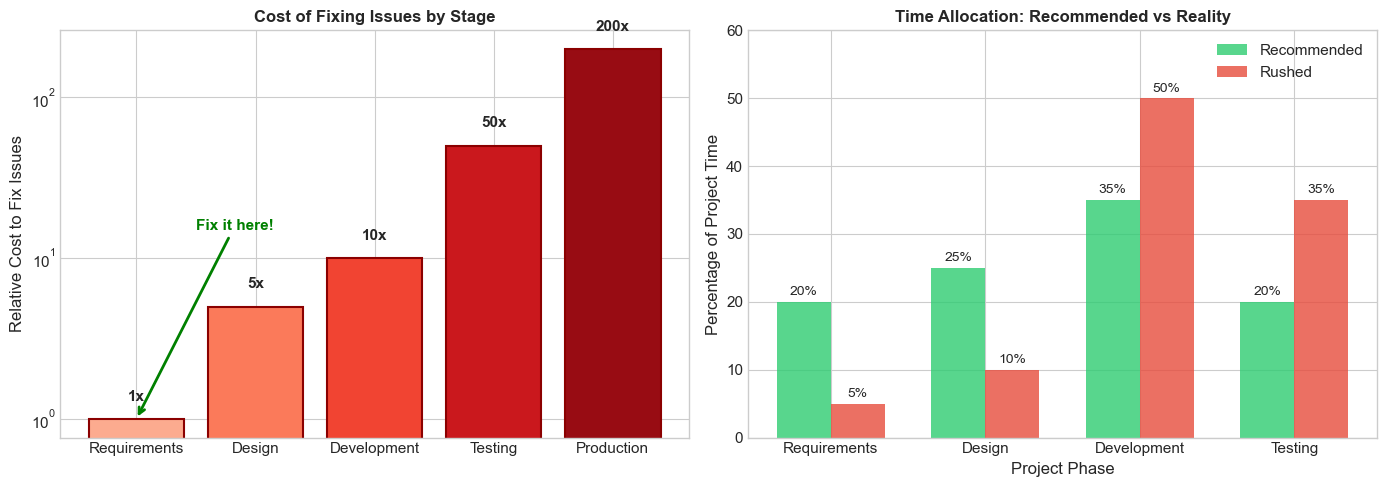

Key Insight: Spending 15-25% of project time on requirements
can reduce overall project cost by 50% or more!


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

stages = ['Requirements', 'Design', 'Development', 'Testing', 'Production']
relative_cost = [1, 5, 10, 50, 200]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(stages)))

bars = ax1.bar(stages, relative_cost, color=colors, edgecolor='darkred', linewidth=1.5)
ax1.set_ylabel('Relative Cost to Fix Issues', fontsize=12)
ax1.set_title('Cost of Fixing Issues by Stage', fontsize=12, fontweight='bold')
ax1.set_yscale('log')

for i, (bar, cost) in enumerate(zip(bars, relative_cost)):
    ax1.text(bar.get_x() + bar.get_width()/2, cost * 1.3, f'{cost}x', 
             ha='center', fontweight='bold', fontsize=11)

ax1.annotate('Fix it here!', xy=(0, 1), xytext=(0.5, 15),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, color='green', fontweight='bold')

phases = ['Requirements', 'Design', 'Development', 'Testing']
ideal_time = [20, 25, 35, 20]
rushed_time = [5, 10, 50, 35]

x = np.arange(len(phases))
width = 0.35

bars1 = ax2.bar(x - width/2, ideal_time, width, label='Recommended', color='#2ecc71', alpha=0.8)
bars2 = ax2.bar(x + width/2, rushed_time, width, label='Rushed', color='#e74c3c', alpha=0.8)

ax2.set_xlabel('Project Phase', fontsize=12)
ax2.set_ylabel('Percentage of Project Time', fontsize=12)
ax2.set_title('Time Allocation: Recommended vs Reality', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(phases)
ax2.legend()
ax2.set_ylim(0, 60)

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.0f}%', ha='center', fontsize=10)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.0f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Key Insight: Spending 15-25% of project time on requirements")
print("can reduce overall project cost by 50% or more!")

### The Three Deadly Sins of Skipping Requirements

| Sin | Description | Example |
|-----|-------------|----------|
| **Building the Wrong Thing** | The system works, but doesn't solve the actual problem | Built a recommendation system when they needed a search system |
| **Over-Engineering** | The system is too complex for the actual needs | Built a distributed system for 1,000 users |
| **Under-Engineering** | The system can't handle actual requirements | Built a batch system when real-time was needed |

---

## Part 2: The Requirements Gathering Framework

Think of requirements gathering like being a detective. You need to ask the right questions to uncover the complete picture.

### The Six Categories of Questions

Every ML system has requirements in six key areas:

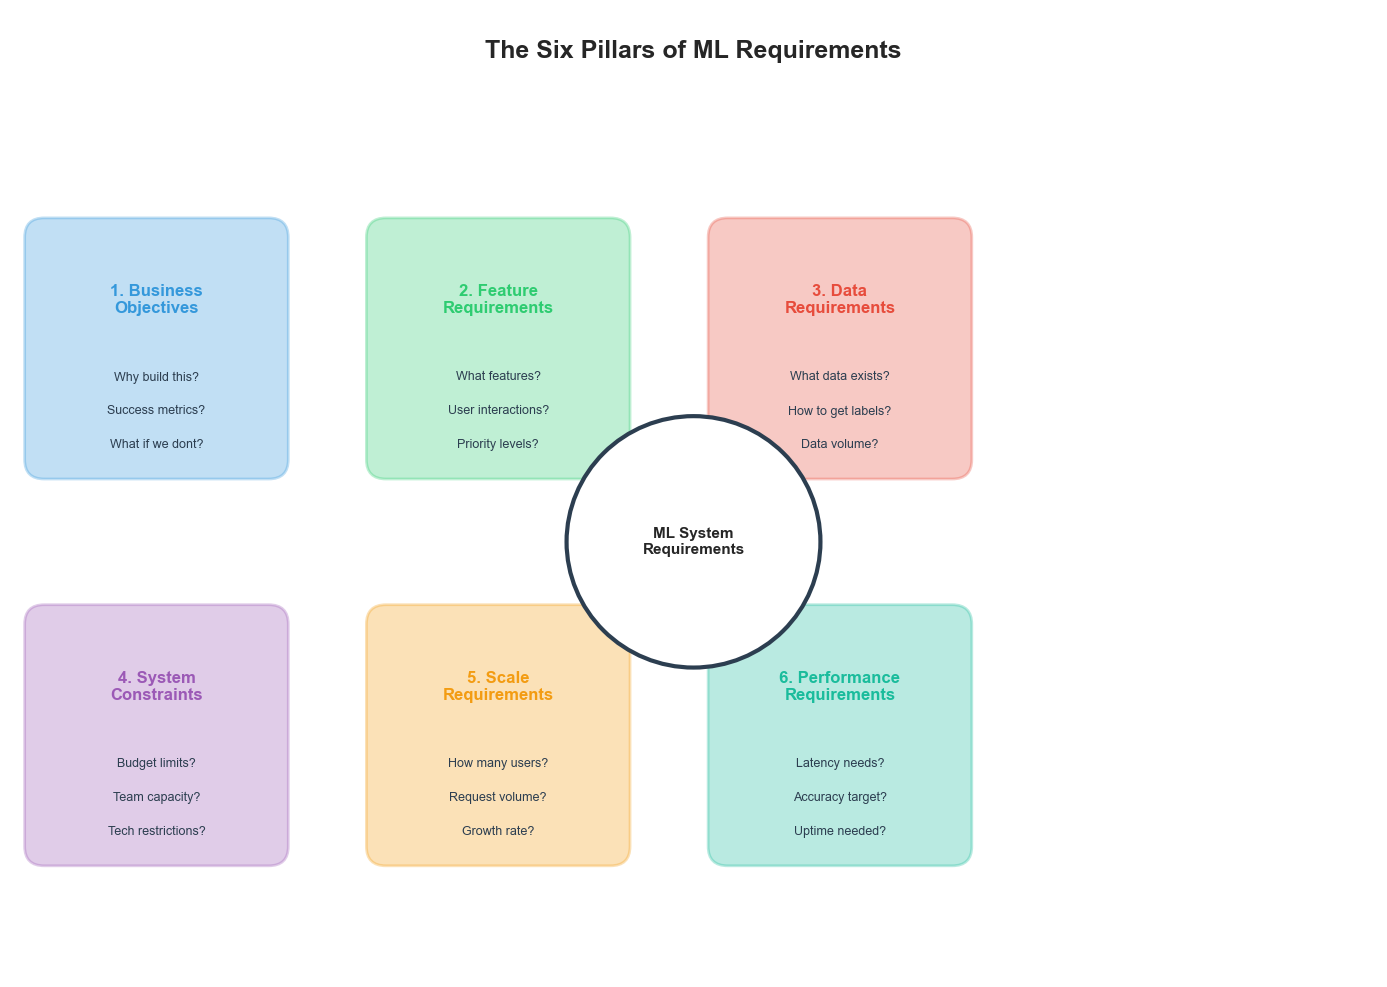

In [3]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(7, 9.5, 'The Six Pillars of ML Requirements', 
        fontsize=18, ha='center', fontweight='bold')

categories = [
    {'name': '1. Business\nObjectives', 'color': '#3498db', 'x': 1.5, 'y': 6.5,
     'questions': ['Why build this?', 'Success metrics?', 'What if we dont?']},
    {'name': '2. Feature\nRequirements', 'color': '#2ecc71', 'x': 5, 'y': 6.5,
     'questions': ['What features?', 'User interactions?', 'Priority levels?']},
    {'name': '3. Data\nRequirements', 'color': '#e74c3c', 'x': 8.5, 'y': 6.5,
     'questions': ['What data exists?', 'How to get labels?', 'Data volume?']},
    {'name': '4. System\nConstraints', 'color': '#9b59b6', 'x': 1.5, 'y': 2.5,
     'questions': ['Budget limits?', 'Team capacity?', 'Tech restrictions?']},
    {'name': '5. Scale\nRequirements', 'color': '#f39c12', 'x': 5, 'y': 2.5,
     'questions': ['How many users?', 'Request volume?', 'Growth rate?']},
    {'name': '6. Performance\nRequirements', 'color': '#1abc9c', 'x': 8.5, 'y': 2.5,
     'questions': ['Latency needs?', 'Accuracy target?', 'Uptime needed?']}
]

for cat in categories:
    rect = FancyBboxPatch((cat['x']-1.3, cat['y']-1.3), 2.6, 2.6,
                          boxstyle="round,pad=0.05,rounding_size=0.2",
                          facecolor=cat['color'], alpha=0.3,
                          edgecolor=cat['color'], linewidth=2)
    ax.add_patch(rect)
    
    ax.text(cat['x'], cat['y']+0.5, cat['name'], 
            fontsize=12, ha='center', va='center', fontweight='bold',
            color=cat['color'])
    
    for i, q in enumerate(cat['questions']):
        ax.text(cat['x'], cat['y']-0.3-i*0.35, q, 
                fontsize=9, ha='center', va='center', color='#2c3e50')

circle = Circle((7, 4.5), 1.3, facecolor='white', edgecolor='#2c3e50', linewidth=3)
ax.add_patch(circle)
ax.text(7, 4.5, 'ML System\nRequirements', fontsize=11, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Quick Reference: The Six Pillars

| Pillar | Focus | Key Question |
|--------|-------|-------------|
| **Business Objectives** | The "WHY" | What problem are we solving? |
| **Feature Requirements** | The "WHAT" | What functionality is needed? |
| **Data Requirements** | The "WITH WHAT" | What data do we have/need? |
| **System Constraints** | The "LIMITS" | What are our restrictions? |
| **Scale Requirements** | The "HOW MUCH" | How big does it need to be? |
| **Performance Requirements** | The "HOW WELL" | How fast/accurate must it be? |

---

## Part 3: Business Objective Questions

The business objective is the **North Star** of your ML system.

### The Restaurant Analogy

Imagine opening a restaurant. Before designing the menu or kitchen, you need to answer:

- **Who are your customers?** (Families? Business professionals? Students?)
- **What's your goal?** (Maximize covers? Build loyalty? Quick turnover?)
- **How do you measure success?** (Revenue? Reviews? Repeat customers?)

In [4]:
business_questions = {
    "Primary Objective": [
        "What is the main business goal this ML system should achieve?",
        "How does this align with the company's overall strategy?",
        "What happens if we don't build this system?",
        "Who requested this project and why?",
    ],
    "Success Metrics": [
        "How will we measure if the system is successful?",
        "What's the current baseline for these metrics?",
        "What improvement would be considered a win?",
        "Are there any metrics we must NOT hurt? (guardrails)",
    ],
    "Trade-offs": [
        "Revenue vs user experience - which takes priority?",
        "Short-term gains vs long-term retention?",
        "Accuracy vs speed - where's the balance?",
        "Precision vs recall - what's the cost of each error type?",
    ],
    "Stakeholders": [
        "Who are the primary users of this system?",
        "Who are the internal stakeholders?",
        "Who has the final say on requirements?",
        "Who will be affected by this system's decisions?",
    ]
}

print("Business Objective Questions Framework")
print("=" * 60)

for category, questions in business_questions.items():
    print(f"\n{category}:")
    print("-" * 40)
    for i, q in enumerate(questions, 1):
        print(f"   {i}. {q}")

Business Objective Questions Framework

Primary Objective:
----------------------------------------
   1. What is the main business goal this ML system should achieve?
   2. How does this align with the company's overall strategy?
   3. What happens if we don't build this system?
   4. Who requested this project and why?

Success Metrics:
----------------------------------------
   1. How will we measure if the system is successful?
   2. What's the current baseline for these metrics?
   3. What improvement would be considered a win?
   4. Are there any metrics we must NOT hurt? (guardrails)

Trade-offs:
----------------------------------------
   1. Revenue vs user experience - which takes priority?
   2. Short-term gains vs long-term retention?
   3. Accuracy vs speed - where's the balance?
   4. Precision vs recall - what's the cost of each error type?

Stakeholders:
----------------------------------------
   1. Who are the primary users of this system?
   2. Who are the internal s

### Mapping Business Objectives to ML Metrics

One of the trickiest parts of ML system design is **translating business goals into ML objectives**.

> **Key Insight**: Business metrics are rarely directly optimizable by ML. We need **proxy metrics** that:
> 1. ML can optimize
> 2. Are correlated with business success
> 3. Can be measured in real-time

In [5]:
objective_mapping = pd.DataFrame({
    'Business Objective': [
        'Increase Revenue',
        'Improve Engagement',
        'Reduce Churn',
        'Improve Safety',
        'Improve Search',
        'Reduce Support Costs'
    ],
    'Business Metric': [
        'GMV, Revenue per user',
        'DAU, Time spent, Session count',
        'Monthly retention rate',
        'User reports, Trust scores',
        'Search success rate',
        'Support tickets, Resolution time'
    ],
    'Proxy Metric (ML)': [
        'Conversion rate, CTR',
        'Engagement score, Watch time',
        'Churn probability',
        'Harmful content detection rate',
        'NDCG, MRR',
        'FAQ click-through, Bot resolution'
    ],
    'ML Target': [
        'P(purchase | user, item)',
        'P(engage | user, content)',
        'P(churn | user, history)',
        'P(harmful | content)',
        'Relevance(query, doc)',
        'P(resolved | user, query)'
    ],
    'Example System': [
        'Product recommendations',
        'Content/video recommendations',
        'Churn prediction',
        'Content moderation',
        'Search ranking',
        'Chatbot / FAQ system'
    ]
})

print("Business Objective to ML Metric Mapping")
print("="*80)
display(objective_mapping)

Business Objective to ML Metric Mapping


,Business Objective,Business Metric,Proxy Metric (ML),ML Target,Example System
0,Increase Revenue,"GMV, Revenue per user","Conversion rate, CTR","P(purchase | user, item)",Product recommendations
1,Improve Engagement,"DAU, Time spent, Session count","Engagement score, Watch time","P(engage | user, content)",Content/video recommendations
2,Reduce Churn,Monthly retention rate,Churn probability,"P(churn | user, history)",Churn prediction
3,Improve Safety,"User reports, Trust scores",Harmful content detection rate,P(harmful | content),Content moderation
4,Improve Search,Search success rate,"NDCG, MRR","Relevance(query, doc)",Search ranking
5,Reduce Support Costs,"Support tickets, Resolution time","FAQ click-through, Bot resolution","P(resolved | user, query)",Chatbot / FAQ system


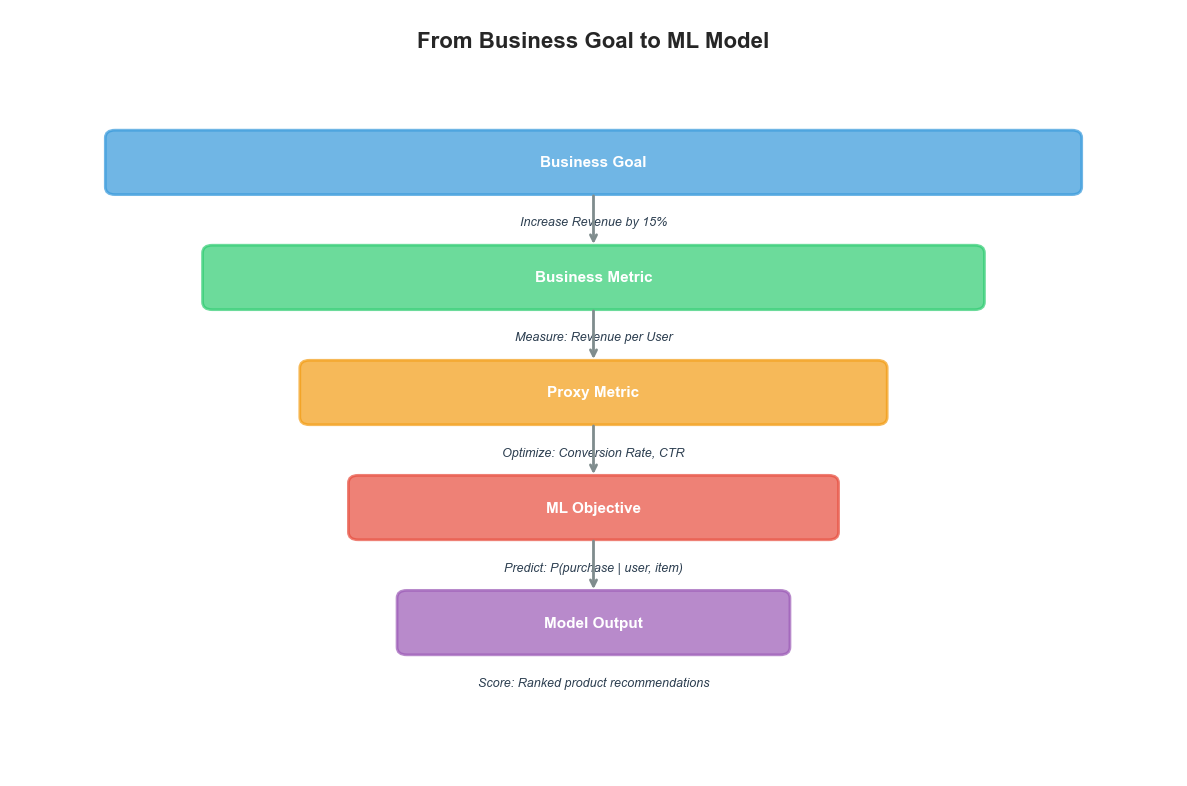

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(6, 9.5, 'From Business Goal to ML Model', 
        fontsize=16, ha='center', fontweight='bold')

stages = [
    {'y': 8, 'width': 10, 'label': 'Business Goal', 
     'example': 'Increase Revenue by 15%', 'color': '#3498db'},
    {'y': 6.5, 'width': 8, 'label': 'Business Metric', 
     'example': 'Measure: Revenue per User', 'color': '#2ecc71'},
    {'y': 5, 'width': 6, 'label': 'Proxy Metric', 
     'example': 'Optimize: Conversion Rate, CTR', 'color': '#f39c12'},
    {'y': 3.5, 'width': 5, 'label': 'ML Objective', 
     'example': 'Predict: P(purchase | user, item)', 'color': '#e74c3c'},
    {'y': 2, 'width': 4, 'label': 'Model Output', 
     'example': 'Score: Ranked product recommendations', 'color': '#9b59b6'},
]

for i, stage in enumerate(stages):
    x_start = 6 - stage['width']/2
    rect = FancyBboxPatch((x_start, stage['y']-0.4), stage['width'], 0.8,
                          boxstyle="round,pad=0.02,rounding_size=0.1",
                          facecolor=stage['color'], alpha=0.7,
                          edgecolor=stage['color'], linewidth=2)
    ax.add_patch(rect)
    
    ax.text(6, stage['y'], stage['label'], fontsize=11, 
            ha='center', va='center', fontweight='bold', color='white')
    ax.text(6, stage['y']-0.7, stage['example'], fontsize=9, 
            ha='center', va='top', style='italic', color='#2c3e50')
    
    if i < len(stages) - 1:
        ax.annotate('', xy=(6, stages[i+1]['y']+0.4), xytext=(6, stage['y']-0.4),
                   arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

plt.tight_layout()
plt.show()

---

## Part 4: Feature Requirements

Feature requirements define **WHAT** the system needs to do from the user's perspective.

### The Smartphone Analogy

When designing a smartphone, features have different priorities:

- **P0 (Must-Have)**: Make calls, send texts, access internet
- **P1 (Should-Have)**: Camera, GPS, App store
- **P2 (Nice-to-Have)**: Face ID, wireless charging, water resistance

In [7]:
@dataclass
class FeatureRequirement:
    """Represents a feature requirement for an ML system."""
    name: str
    description: str
    priority: str
    user_interaction: str
    ml_implication: str
    complexity: str = "Medium"

features = [
    FeatureRequirement(
        name="Personalized Home Feed",
        description="Show personalized video recommendations on home page",
        priority="P0",
        user_interaction="User opens the app",
        ml_implication="Real-time ranking model, user embeddings",
        complexity="High"
    ),
    FeatureRequirement(
        name="Like/Dislike Buttons",
        description="Allow users to express explicit preferences",
        priority="P0",
        user_interaction="User clicks thumbs up/down",
        ml_implication="Explicit feedback collection",
        complexity="Low"
    ),
    FeatureRequirement(
        name="Related Videos",
        description="Show similar videos when watching content",
        priority="P1",
        user_interaction="User scrolls on video page",
        ml_implication="Content-based similarity model",
        complexity="Medium"
    ),
    FeatureRequirement(
        name="Continue Watching",
        description="Resume partially watched videos",
        priority="P1",
        user_interaction="User returns to the app",
        ml_implication="Watch history tracking",
        complexity="Low"
    ),
    FeatureRequirement(
        name="Surprise Me",
        description="Show unexpected but interesting recommendations",
        priority="P2",
        user_interaction="User clicks Surprise Me button",
        ml_implication="Exploration vs exploitation",
        complexity="High"
    ),
]

features_df = pd.DataFrame([{
    'Feature': f.name,
    'Priority': f.priority,
    'Complexity': f.complexity,
    'User Action': f.user_interaction,
    'ML Components': f.ml_implication
} for f in features])

print("Feature Requirements: Video Recommendation System")
print("=" * 70)
display(features_df)

Feature Requirements: Video Recommendation System


,Feature,Priority,Complexity,User Action,ML Components
0,Personalized Home Feed,P0,High,User opens the app,"Real-time ranking model, user embeddings"
1,Like/Dislike Buttons,P0,Low,User clicks thumbs up/down,Explicit feedback collection
2,Related Videos,P1,Medium,User scrolls on video page,Content-based similarity model
3,Continue Watching,P1,Low,User returns to the app,Watch history tracking
4,Surprise Me,P2,High,User clicks Surprise Me button,Exploration vs exploitation


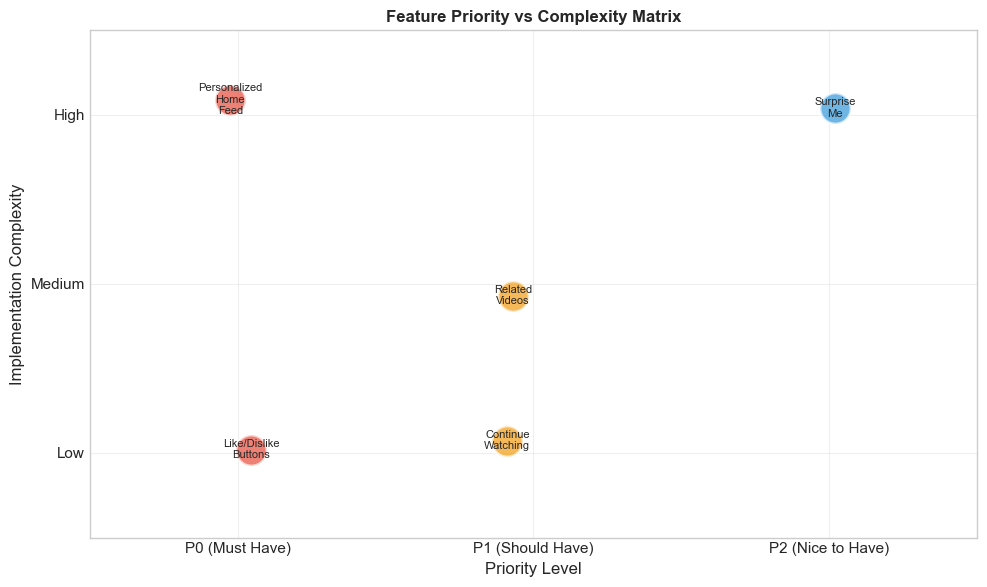

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

priority_colors = {'P0': '#e74c3c', 'P1': '#f39c12', 'P2': '#3498db'}
complexity_order = {'Low': 1, 'Medium': 2, 'High': 3}

np.random.seed(42)
for f in features:
    x = list(priority_colors.keys()).index(f.priority) + np.random.uniform(-0.1, 0.1)
    y = complexity_order[f.complexity] + np.random.uniform(-0.1, 0.1)
    ax.scatter(x, y, s=500, c=priority_colors[f.priority], alpha=0.7, edgecolors='white', linewidth=2)
    ax.annotate(f.name.replace(' ', '\n'), (x, y), ha='center', va='center', fontsize=8)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['P0 (Must Have)', 'P1 (Should Have)', 'P2 (Nice to Have)'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Priority Level', fontsize=12)
ax.set_ylabel('Implementation Complexity', fontsize=12)
ax.set_title('Feature Priority vs Complexity Matrix', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(0.5, 3.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 5: Data Requirements

**No data = No ML.** Understanding your data is crucial before building any ML system.

### The Cooking Analogy

ML systems are like cooking:
- **Ingredients = Data**: You can't cook without ingredients
- **Recipe = Algorithm**: The algorithm transforms data into predictions
- **Chef = ML Engineer**: Combines the right ingredients with the right technique

In [9]:
data_questions = {
    "Data Availability": [
        "What data do we currently have access to?",
        "What additional data could we collect?",
        "Are there any data access restrictions?",
        "Is the data in a usable format?",
    ],
    "Data Labeling": [
        "Is the data already labeled?",
        "Can we use implicit labels (clicks, purchases)?",
        "What's the cost and timeline for manual labeling?",
        "How confident are we in the label quality?",
    ],
    "Data Volume": [
        "How much data do we have? (rows, size in GB/TB)",
        "What's the data growth rate?",
        "How far back do we have historical data?",
        "Is this enough data for ML?",
    ],
    "Data Quality": [
        "How complete is the data? (missing values)",
        "How accurate is the data?",
        "Is the data biased in any way?",
        "Is the data representative of production traffic?",
    ]
}

print("Data Requirements Questions")
print("=" * 60)

for category, questions in data_questions.items():
    print(f"\n{category}:")
    print("-" * 40)
    for i, q in enumerate(questions, 1):
        print(f"   {i}. {q}")

Data Requirements Questions

Data Availability:
----------------------------------------
   1. What data do we currently have access to?
   2. What additional data could we collect?
   3. Are there any data access restrictions?
   4. Is the data in a usable format?

Data Labeling:
----------------------------------------
   1. Is the data already labeled?
   2. Can we use implicit labels (clicks, purchases)?
   3. What's the cost and timeline for manual labeling?
   4. How confident are we in the label quality?

Data Volume:
----------------------------------------
   1. How much data do we have? (rows, size in GB/TB)
   2. What's the data growth rate?
   3. How far back do we have historical data?
   4. Is this enough data for ML?

Data Quality:
----------------------------------------
   1. How complete is the data? (missing values)
   2. How accurate is the data?
   3. Is the data biased in any way?
   4. Is the data representative of production traffic?


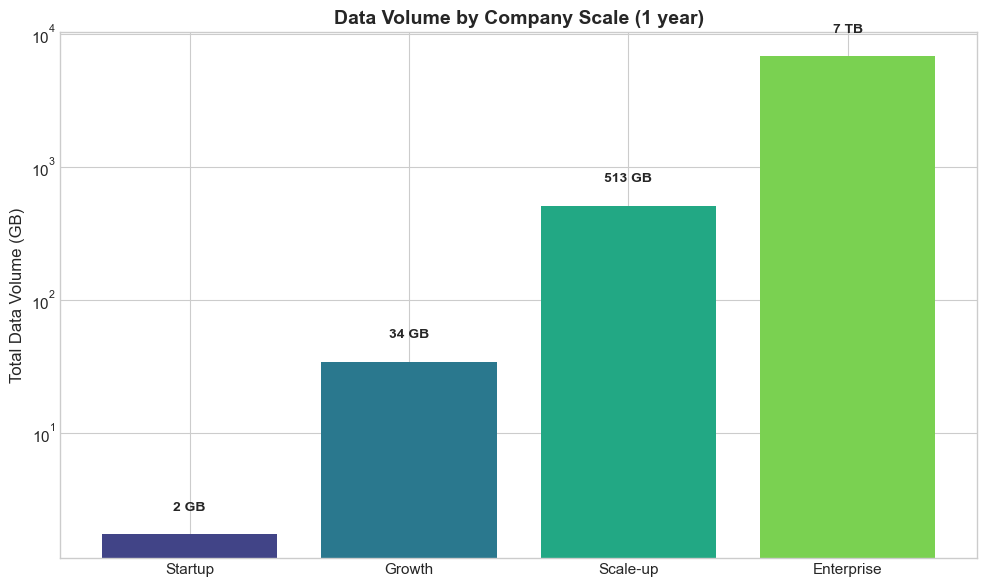

In [10]:
def estimate_data_volume(users, items, interactions_per_day, days=365):
    """Estimate data volume for an ML system."""
    bytes_per_interaction = 100
    bytes_per_user = 2048
    bytes_per_item = 10240
    
    total_interactions = users * interactions_per_day * days
    interaction_gb = (total_interactions * bytes_per_interaction) / (1024**3)
    user_gb = (users * bytes_per_user) / (1024**3)
    item_gb = (items * bytes_per_item) / (1024**3)
    total_gb = interaction_gb + user_gb + item_gb
    
    return {'total_gb': total_gb}

scenarios = [
    {"name": "Startup", "users": 10_000, "items": 1_000, "interactions": 5},
    {"name": "Growth", "users": 100_000, "items": 10_000, "interactions": 10},
    {"name": "Scale-up", "users": 1_000_000, "items": 100_000, "interactions": 15},
    {"name": "Enterprise", "users": 10_000_000, "items": 1_000_000, "interactions": 20},
]

results = []
for s in scenarios:
    est = estimate_data_volume(s["users"], s["items"], s["interactions"])
    results.append({
        'Scenario': s['name'],
        'Users': f"{s['users']:,}",
        'Items': f"{s['items']:,}",
        'Total GB': est['total_gb'],
    })

fig, ax = plt.subplots(figsize=(10, 6))

names = [r['Scenario'] for r in results]
data_gb = [r['Total GB'] for r in results]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))

bars = ax.bar(names, data_gb, color=colors)
ax.set_ylabel('Total Data Volume (GB)', fontsize=12)
ax.set_title('Data Volume by Company Scale (1 year)', fontsize=14, fontweight='bold')
ax.set_yscale('log')

for bar, gb in zip(bars, data_gb):
    label = f'{gb/1024:,.0f} TB' if gb > 1024 else f'{gb:,.0f} GB'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5, label,
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Implicit vs Explicit Labels

| Label Type | Examples | Pros | Cons |
|------------|----------|------|------|
| **Explicit** | Ratings, reviews, thumbs up/down | High signal, clear intent | Low volume, selection bias |
| **Implicit** | Clicks, watch time, purchases | High volume, natural behavior | Noisy, ambiguous intent |
| **Human Annotation** | Labeled by experts | High quality, customizable | Expensive, slow |

---

## Part 6: System Constraints

Constraints define what's **NOT possible**. Understanding them early saves time and money.

In [11]:
@dataclass
class SystemConstraint:
    """Represents a system constraint."""
    category: str
    constraint: str
    requirement: str
    impact: str

constraints = [
    SystemConstraint("Deployment", "Platform", "Must run on AWS", "Limits to AWS services"),
    SystemConstraint("Performance", "Latency", "p99 < 100ms", "Need caching, simple models"),
    SystemConstraint("Performance", "Throughput", "10,000 RPS", "Need horizontal scaling"),
    SystemConstraint("Resources", "Budget", "$30K/month", "Limits model complexity"),
    SystemConstraint("Team", "ML Engineers", "2 engineers", "Prefer simpler solutions"),
    SystemConstraint("Privacy", "Data Location", "EU only (GDPR)", "Regional deployment"),
]

constraints_df = pd.DataFrame([{
    'Category': c.category,
    'Constraint': c.constraint,
    'Requirement': c.requirement,
    'Impact': c.impact
} for c in constraints])

print("Common System Constraints")
print("="*80)
display(constraints_df)

Common System Constraints


,Category,Constraint,Requirement,Impact
0,Deployment,Platform,Must run on AWS,Limits to AWS services
1,Performance,Latency,p99 < 100ms,"Need caching, simple models"
2,Performance,Throughput,"10,000 RPS",Need horizontal scaling
3,Resources,Budget,$30K/month,Limits model complexity
4,Team,ML Engineers,2 engineers,Prefer simpler solutions
5,Privacy,Data Location,EU only (GDPR),Regional deployment


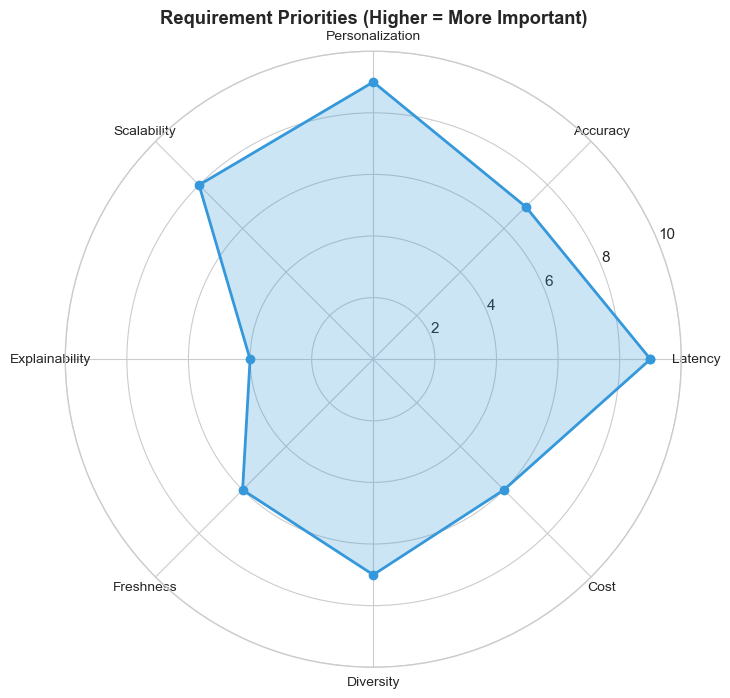

In [12]:
def plot_radar(requirements, title):
    """Create a radar chart for requirement priorities."""
    categories = list(requirements.keys())
    values = list(requirements.values())
    values += values[:1]
    
    angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, values, 'o-', linewidth=2, color='#3498db')
    ax.fill(angles, values, alpha=0.25, color='#3498db')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 10)
    ax.set_title(title, fontweight='bold', pad=20)
    return fig

reqs = {
    'Latency': 9, 'Accuracy': 7, 'Personalization': 9, 'Scalability': 8,
    'Explainability': 4, 'Freshness': 6, 'Diversity': 7, 'Cost': 6
}

fig = plot_radar(reqs, "Requirement Priorities (Higher = More Important)")
plt.show()

---

## Part 7: Scale Requirements

Scale determines architecture decisions, infrastructure needs, and cost.

In [ ]:
scale_questions = {
    "User Scale": [
        "How many total users?",
        "How many daily active users (DAU)?",
        "Expected growth rate?",
    ],
    "Item Scale": [
        "How many items in the catalog?",
        "How frequently are items added?",
        "How many categories of items?",
    ],
    "Request Scale": [
        "Average requests per second?",
        "Peak requests per second?",
        "Traffic variation patterns?",
    ]
}

print("Scale Questions")
print("="*50)
for category, questions in scale_questions.items():
    print(f"\n{category}:")
    for q in questions:
        print(f"  - {q}")

In [ ]:
scale_tiers = pd.DataFrame({
    'Tier': ['Startup', 'Growth', 'Scale', 'Hyperscale'],
    'Users': ['<100K', '100K-1M', '1M-100M', '>100M'],
    'RPS': ['<100', '100-1K', '1K-10K', '>10K'],
    'Architecture': ['Monolithic', 'Microservices', 'Distributed', 'Global multi-region'],
    'Model Complexity': ['Simple (sklearn)', 'Moderate (XGBoost)', 'Complex (DL)', 'Ensemble'],
    'Monthly Cost': ['$100-1K', '$1K-10K', '$10K-100K', '$100K+']
})

print("Scale Tiers and Implications")
display(scale_tiers)

---

## Part 8: Performance Requirements

In [ ]:
performance_questions = {
    "Latency": ["Acceptable response time (p50, p99)?", "Real-time processing needed?"],
    "Freshness": ["How fresh do recommendations need to be?", "Can we use pre-computed results?"],
    "Accuracy": ["What accuracy level is acceptable?", "Cost of wrong predictions?"],
    "Reliability": ["Required uptime (99.9%, 99.99%)?", "Fallback mechanisms needed?"]
}

print("Performance Questions")
for category, questions in performance_questions.items():
    print(f"\n{category}:")
    for q in questions:
        print(f"  - {q}")

In [ ]:
processing = pd.DataFrame({
    'Aspect': ['Latency', 'Freshness', 'Cost', 'Use Cases'],
    'Real-Time': ['Milliseconds', 'Immediate', 'Higher', 'Recommendations, Fraud'],
    'Batch': ['Hours', 'Periodic', 'Lower', 'Email campaigns, Retraining'],
    'Hybrid': ['Varies', 'Mixed', 'Optimized', 'Pre-compute + real-time rank']
})

print("Processing Mode Comparison")
display(processing)

---

## Part 9: Complete Requirements Template

In [ ]:
@dataclass
class MLSystemRequirements:
    """Complete requirements documentation."""
    system_name: str
    business_objective: str = ""
    success_metrics: List[str] = field(default_factory=list)
    deployment_type: str = ""
    latency_requirement: str = ""
    num_users: int = 0
    num_items: int = 0
    requests_per_second: float = 0
    
    def summary(self):
        print(f"\n{'='*60}")
        print(f"ML SYSTEM REQUIREMENTS: {self.system_name}")
        print(f"{'='*60}")
        print(f"\nObjective: {self.business_objective}")
        print(f"\nSuccess Metrics:")
        for m in self.success_metrics:
            print(f"  - {m}")
        print(f"\nScale: {self.num_users:,} users, {self.num_items:,} items, {self.requests_per_second:,} RPS")
        print(f"Deployment: {self.deployment_type}")
        print(f"Latency: {self.latency_requirement}")

reqs = MLSystemRequirements(
    system_name="Video Recommendation System",
    business_objective="Maximize watch time and retention",
    success_metrics=["Increase watch time by 20%", "Improve CTR by 15%"],
    deployment_type="Cloud + Edge caching",
    latency_requirement="p50 < 50ms, p99 < 200ms",
    num_users=50_000_000,
    num_items=10_000_000,
    requests_per_second=50_000
)

reqs.summary()

---

## Part 10: Requirements Checklist

In [ ]:
checklist = """
ML SYSTEM REQUIREMENTS CHECKLIST
================================

BUSINESS REQUIREMENTS:
[ ] Primary business objective defined
[ ] Success metrics identified with baselines
[ ] Target improvement quantified
[ ] Trade-offs discussed and prioritized

FEATURE REQUIREMENTS:
[ ] User interactions documented
[ ] Content/item types specified
[ ] Personalization level defined
[ ] Priority (P0/P1/P2) assigned

DATA REQUIREMENTS:
[ ] Data sources inventoried
[ ] Data volume estimated
[ ] Labeling strategy defined
[ ] Data quality assessed

CONSTRAINTS:
[ ] Deployment type specified
[ ] Latency requirements defined
[ ] Budget constraints documented
[ ] Team capacity assessed

SCALE:
[ ] User scale documented
[ ] Item scale documented
[ ] Request volume estimated
[ ] Growth projections made

PERFORMANCE:
[ ] Accuracy targets set
[ ] Freshness requirements defined
[ ] Availability targets set
[ ] Fallback strategy planned
"""

print(checklist)

---

## Hands-On Exercise

Practice gathering requirements for a content moderation system.

In [ ]:
# TODO: Complete this exercise
# Create requirements for a content moderation system

# content_moderation = MLSystemRequirements(
#     system_name="Content Moderation System",
#     business_objective="...",
#     success_metrics=["..."],
#     deployment_type="...",
#     latency_requirement="...",
#     num_users=...,
#     requests_per_second=...
# )
# content_moderation.summary()

print("Hints for Content Moderation System:")
print("- Business goal: User safety and platform trust")
print("- Key metric: False negative rate (missing harmful content)")
print("- Constraint: Very low latency (content appears quickly)")
print("- Trade-off: Precision vs Recall (over-moderation vs under-moderation)")

---

## Summary

### Key Takeaways

1. **Requirements First**: Always gather requirements before designing the system

2. **Six Categories of Questions**:
   - Business objectives
   - Feature requirements
   - Data requirements
   - Constraints
   - Scale
   - Performance

3. **Document Everything**: Use structured templates to capture requirements

4. **Clarify Trade-offs**: Understand what can be sacrificed for what

### Next Steps

In the next tutorial, we'll learn how to **Frame ML Problems** - translating these requirements into concrete ML objectives.

---

In [ ]:
quiz = [
    ("What percentage of project time should be spent on requirements?", "B", 
     ["A) 5%", "B) 15-25%", "C) 50%", "D) 75%"]),
    ("Which constraint is typically most important for recommendation systems?", "A",
     ["A) Latency", "B) Storage", "C) Team size", "D) None"]),
    ("What's the best labeling strategy when explicit labels are expensive?", "B",
     ["A) Skip labeling", "B) Use implicit signals", "C) Random labels", "D) Expert labels only"])
]

print("Quick Self-Assessment")
print("="*40)
for i, (q, a, opts) in enumerate(quiz, 1):
    print(f"\nQ{i}: {q}")
    for opt in opts:
        print(f"   {opt}")

print("\n" + "="*40)
print("Answers: 1-B, 2-A, 3-B")